In [104]:
from sklearn.datasets import make_blobs 
import matplotlib.pyplot as plt


## Custom Kmeans Class

In [105]:
import random
import numpy as np 

class Kmeans:

    def __init__(self,n_clusters = 2, max_iter = 100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None

    def fit_predict(self, X):
        random_index = random.sample(range(0,X.shape[0]),self.n_clusters)
        self.centroids = X[random_index]
        # print(self.centroids)
        for i in range(self.max_iter):
            # assign clusters 
            cluster_group = self.assign_clusters(X)

            old_centroids = self.centroids
            # move centroids
            self.centroids = self.move_centroids(X,cluster_group)


            # check finish criteria
            if (old_centroids == self.centroids ).all():
                break

        return cluster_group
    

    def assign_clusters(self,X):
        cluster_group=[]
        distances = []
        for row in X:
            for centroid in self.centroids:
                distances.append(np.sqrt(np.dot(row-centroid,row-centroid)))
            # print(distances)
            min_distance = min(distances)
            index_pos = distances.index(min_distance)
            # print(index_pos)
            cluster_group.append(index_pos)
            distances.clear()

        return np.array(cluster_group)

    def move_centroids(self,X,cluster_group):
        new_centroids = []
        cluster_type = np.unique(cluster_group)
        for type in cluster_type:
            new_centroids.append(X[cluster_group == type].mean(axis = 0)) # gives rows which are of the same type in cluster and gives the mean ie new centriod of that cluster
        return np.array(new_centroids)



        

euclidian distance 

In [106]:
import numpy as np 

a = np.array([1,2])
b = np.array([4,5])

np.sqrt(np.dot(b-a,b-a))

np.float64(4.242640687119285)

In [107]:
centroids = [(5,-5),(5,5)]
cluster_std = [1,1]

In [108]:
X,y = make_blobs(n_samples=100, cluster_std=cluster_std , centers=centroids , n_features=3,random_state=2)


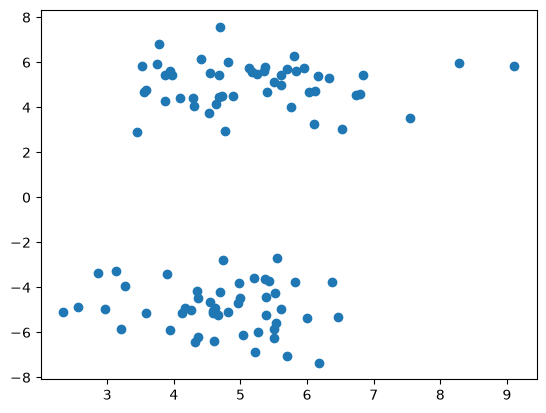

In [109]:
plt.scatter(X[:,0],X[:,1])
plt.show()

In [110]:
km = Kmeans(n_clusters=2, max_iter=100)

In [111]:
y_means  = km.fit_predict(X)

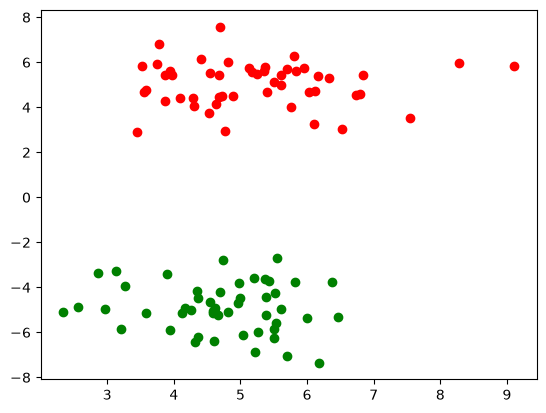

In [112]:
plt.scatter(X[y_means == 0,0], X[y_means == 0,1] , color = 'red')
plt.scatter(X[y_means == 1,0], X[y_means == 1,1] , color = 'green')

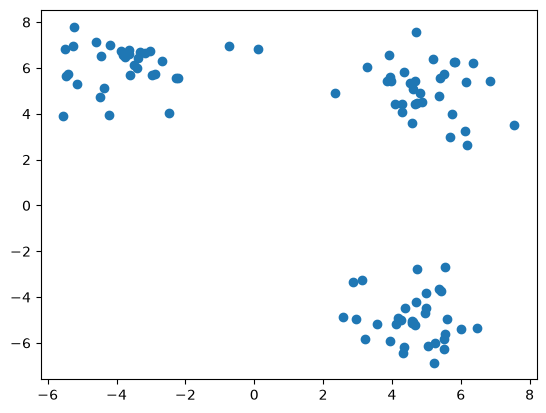

In [113]:
centroids = [(5,-5),(5,5),(-4,6)]
cluster_std = [1,1,1]

X,y = make_blobs(n_samples=100, cluster_std=cluster_std , centers=centroids , n_features=3,random_state=2)

plt.scatter(X[:,0],X[:,1])
plt.show()

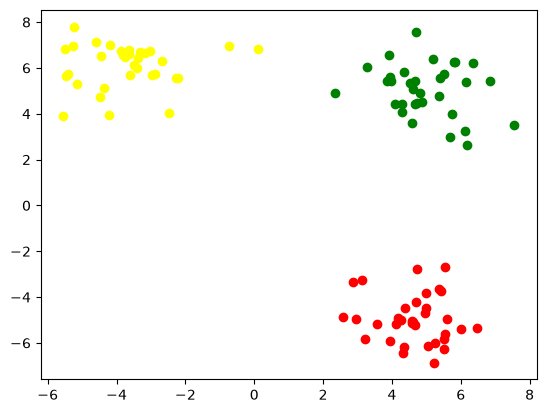

In [114]:
km = Kmeans(n_clusters=3, max_iter=100)
y_means = km.fit_predict(X)
plt.scatter(X[y_means == 0,0], X[y_means == 0,1] , color = 'red')
plt.scatter(X[y_means == 1,0], X[y_means == 1,1] , color = 'green')
plt.scatter(X[y_means == 2,0], X[y_means == 2,1] , color = 'yellow')

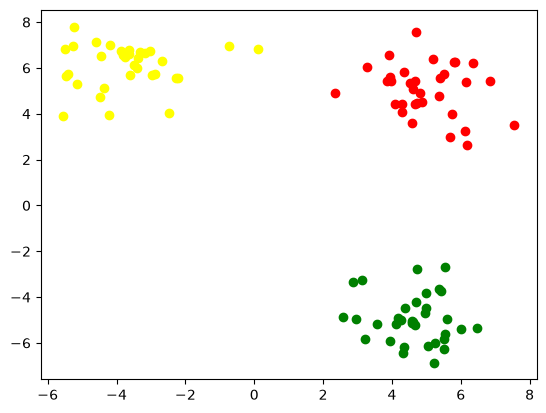

In [115]:
km = Kmeans(n_clusters=3, max_iter=1)
y_means = km.fit_predict(X)
plt.scatter(X[y_means == 0,0], X[y_means == 0,1] , color = 'red')
plt.scatter(X[y_means == 1,0], X[y_means == 1,1] , color = 'green')
plt.scatter(X[y_means == 2,0], X[y_means == 2,1] , color = 'yellow')

So max iteration should be enough 

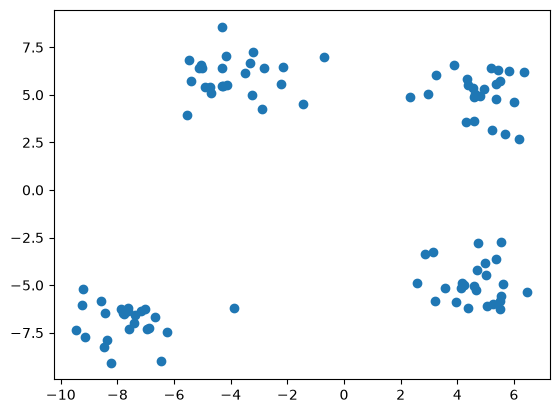

In [116]:
centroids = [(5,-5),(5,5),(-4,6),(-8,-7)]
cluster_std = [1,1,1,1]

X,y = make_blobs(n_samples=100, cluster_std=cluster_std , centers=centroids , n_features=3,random_state=2)

plt.scatter(X[:,0],X[:,1])
plt.show()

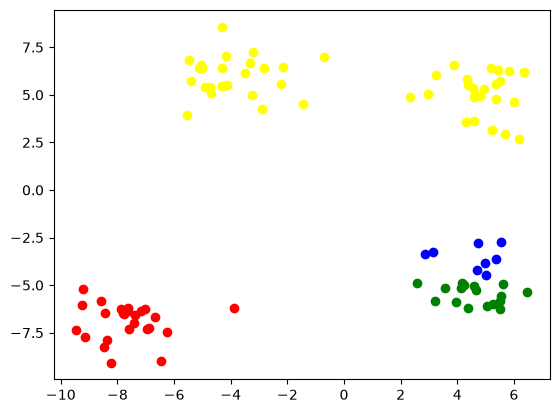

In [117]:
km = Kmeans(n_clusters=4, max_iter=1000)
y_means = km.fit_predict(X)
plt.scatter(X[y_means == 0,0], X[y_means == 0,1] , color = 'red')
plt.scatter(X[y_means == 1,0], X[y_means == 1,1] , color = 'green')
plt.scatter(X[y_means == 2,0], X[y_means == 2,1] , color = 'yellow')
plt.scatter(X[y_means == 3,0], X[y_means == 3,1] , color = 'blue')

Implemenation on the acutal data 

In [118]:
import pandas as pd

df = pd.read_csv('student_clustering.csv')
df.head()

,cgpa,iq
0,5.13,88
1,5.90,113
2,8.36,93
3,8.27,97
4,5.45,110


In [119]:
X_new = df.iloc[:,:].values

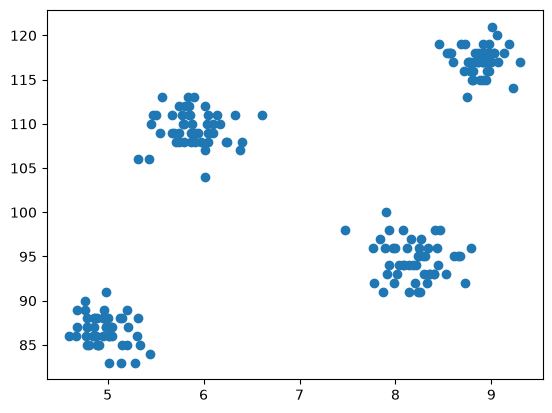

In [120]:
plt.scatter(X_new[:,0],X_new[:,1])
plt.show()

In [121]:
# X_new

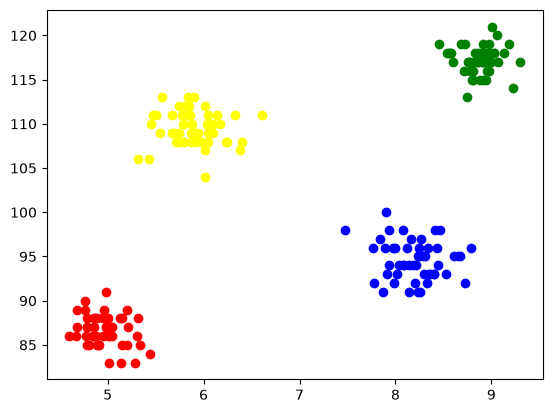

In [124]:
km = Kmeans(n_clusters=4, max_iter=10000)
y_means = km.fit_predict(X_new)
plt.scatter(X_new[y_means == 0,0], X_new[y_means == 0,1] , color = 'red')
plt.scatter(X_new[y_means == 1,0], X_new[y_means == 1,1] , color = 'green')
plt.scatter(X_new[y_means == 2,0], X_new[y_means == 2,1] , color = 'yellow')
plt.scatter(X_new[y_means == 3,0], X_new[y_means == 3,1] , color = 'blue')